In [2]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests
import gseapy as gp
from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt


%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

def calculate_vif(dataframe):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = dataframe.assign(constant=1)
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

major_celltypes = ['B cells',
       'CD4+ T cells', 'MAIT cells', 'Myeloid cells', 'NK cells',
        'TRAV1-2- CD8+ T cells', 'gd T cells']

# Inputs

In [2]:
# - coexp matrix 
coexp_adata = ad.read_h5ad('output/coexp_adata_sla_spearman_False.h5ad')
coexp_adata.obs[['age_donor','sample']] =  coexp_adata.obs['age_donor'].str.rsplit('_', n=1, expand=True)

# - add cell type ratio from the original deta to coexp adata obs
obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)

obs = obs[['Batch', 'Donor_id','Age','Cluster_names', 'Sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

cell_type_counts = obs.groupby(['age_donor', 'cell_type']).size().unstack(fill_value=0) #TODO: shorten cell types


if False: # ratios versus each other 
    cell_type_ratios = cell_type_counts.div(cell_type_counts.sum(axis=1), axis=0).reset_index()
else: # ratios versus each other 
    cell_type_ratios = cell_type_counts.div(cell_type_counts['CD4+ T cells'], axis=0).reset_index()
    
coexp_obs = coexp_adata.obs.merge(cell_type_counts, on='age_donor', how='left')

# - extract sig links (targets)
sig_oo = pd.read_csv('output/links_pvalues_vs_34_sla_spearman_False.csv', index_col=0)

sig_oo['bonferroni'] = multipletests(sig_oo['pvalue'], alpha=0.05, method='bonferroni')[1]
sig_oo['fdr'] = multipletests(sig_oo['pvalue'], alpha=0.05, method='fdr_bh')[1]

mask = (sig_oo['fdr']<0.05)
sig_oo = sig_oo[mask]
sig_links = sig_oo.link.unique()
print('# of sig links',len(sig_links))
sig_oo.age_group.value_counts()

# of sig links 836


age_group
65_75    502
45_54    357
55_64    258
35_44    158
Name: count, dtype: int64

## Enrichment analysis of the sig links

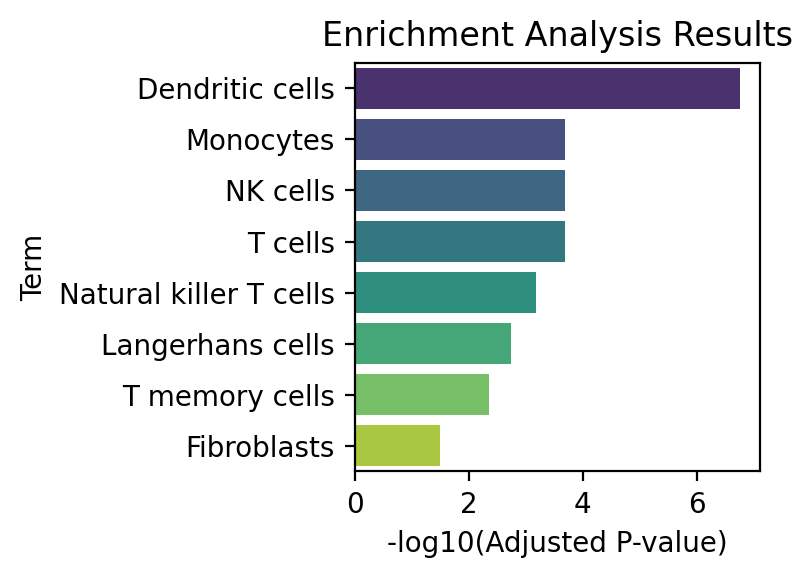

In [4]:
gg_names = np.asarray([name.split('_') for name in sig_oo.link.unique()])
gene_names = np.unique(gg_names.flatten())

enr = gp.enrichr(
    gene_list=list(gene_names),     # List of genes
    gene_sets='../grn_benchmark/output/panglaodb_marker_sets.gmt',  #KEGG_2021_Human 'GO_Biological_Process_2021'
    # gene_sets='GO_Biological_Process_2021',  #KEGG_2021_Human 'GO_Biological_Process_2021'
    organism='Human',         # Organism
    outdir='output/enrichr_results', # Output directory
)

enrich_rr = enr.results
enrich_rr = enrich_rr[enrich_rr['Adjusted P-value']<0.05][['Term', 'Overlap', 'Adjusted P-value', 'Genes']]
plot_enrichment(enrich_rr, figsize=(4,3))

# Cell type ratios across age groups

In [6]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
coexp_obs_df = coexp_obs[major_celltypes+['age_group']].set_index('age_group')
# Assuming df is your DataFrame with age groups as index and cell types as columns
cell_type_ratios = coexp_obs_df.div(coexp_obs_df.sum(axis=1), axis=0)

def calculate_sig_cell_type_change(df):
    # Initialize a DataFrame to store p-values and mean comparisons
    p_values = pd.DataFrame(index=df.columns, columns=df.index.unique())
    mean_comparisons = pd.DataFrame(index=df.columns, columns=df.index.unique())

    # Loop over each age group
    for age_group in df.index.unique():
        # Loop over each cell type
        for cell_type in df.columns:
            # Define the test group and the background
            test_group = df.loc[age_group, cell_type]
            background = df.loc[df.index == '34-', cell_type]
            
            # Calculate means
            mean_test = test_group.mean()
            mean_background = background.mean()

            # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(test_group.values, background.values, alternative='two-sided')
            
            # Store the p-value and mean comparison sign
            p_values.loc[cell_type, age_group] = p_value
            if mean_test > mean_background:
                mean_comparisons.loc[cell_type, age_group] = 1  # Positive change
            elif mean_test < mean_background:
                mean_comparisons.loc[cell_type, age_group] = -1  # Negative change
            else:
                mean_comparisons.loc[cell_type, age_group] = 0  # No change

    # Reset index and melt the p-values DataFrame
    p_values = p_values.reset_index().melt(id_vars='index', var_name='age_group', value_name='pvalue')
    mean_comparisons = mean_comparisons.reset_index().melt(id_vars='index', var_name='age_group', value_name='mean_change')

    # Calculate FDR for p-values
    p_values['fdr'] = multipletests(p_values['pvalue'], method='bonferroni')[1]

    # Merge FDR and mean change sign
    results = pd.merge(p_values, mean_comparisons, on=['index', 'age_group'])

    results['final_fdr'] = results['fdr'] * results['mean_change']
    pivoted_results = results.pivot(index='index', columns='age_group', values='final_fdr')
    return pivoted_results
pivoted_results = calculate_sig_cell_type_change(cell_type_ratios)

# Display the pivoted results
print(pivoted_results)

age_group             34-     35_44 45_54     55_64     65_75
index                                                        
B cells                 0        -1    -1 -0.614096 -0.146159
CD4+ T cells            0         1     1         1         1
MAIT cells              0        -1    -1 -0.000232 -0.000024
Myeloid cells           0         1     1        -1  0.016356
NK cells                0         1    -1         1  0.112202
TRAV1-2- CD8+ T cells   0        -1    -1 -0.107296      -0.0
gd T cells              0 -0.036455     1  0.022233 -0.000033


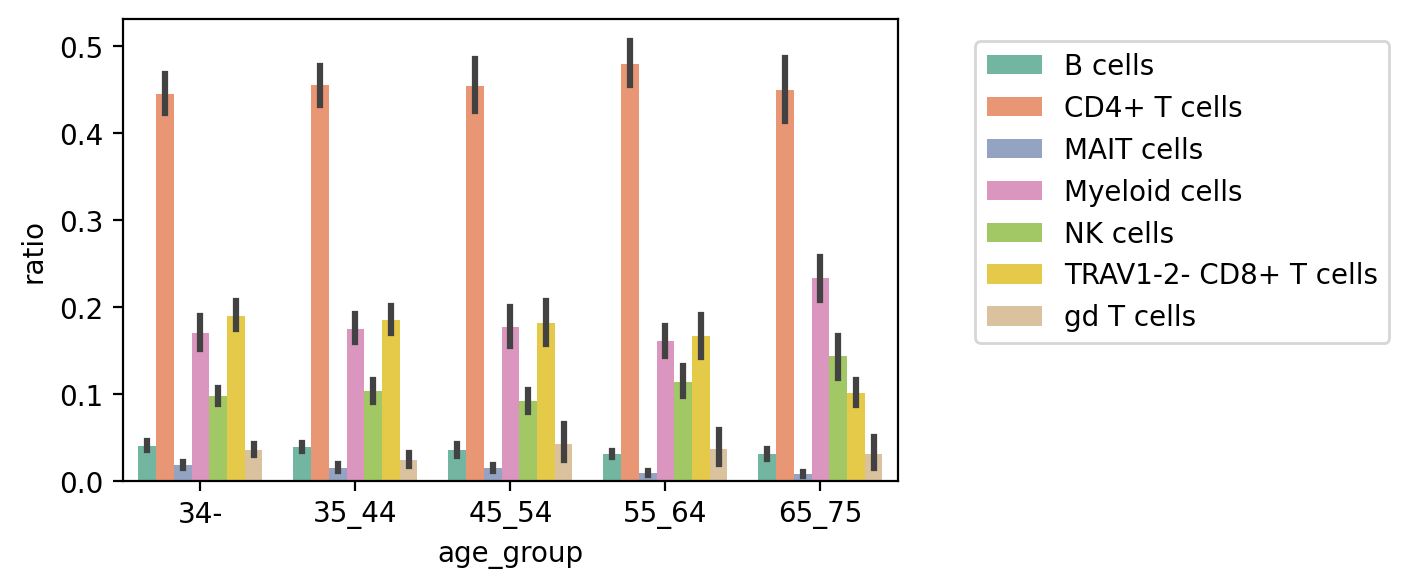

In [11]:
plt.figure(figsize=(5, 3))
df_long = cell_type_ratios.reset_index().melt(id_vars='age_group', var_name='cell_type', value_name='ratio')
palette = sns.color_palette("Set2", n_colors=df_long['cell_type'].nunique())
sns.barplot(df_long, x='age_group', y='ratio', hue='cell_type', palette=palette)
plt.legend(loc=(1.1, .3))

# Cell type ratios predicts coexp

In [7]:
# - choose target for the reg (either sig links or a bigger space)
if False:
    target_links = np.unique(np.concatenate([np.random.choice(coexp_adata.var_names, 10000), sig_links]))
else:
    target_links = sig_links

In [8]:
# - run regression model
from src.helper import predict_celltype_ratio_from_coexp

if False:
    if True:
        # - prepare feature and target space 
        ref_cell_type = 'CD4+ T cells'
        coexp_obs = coexp_obs[major_celltypes]
        cell_type_ratios_normalized = coexp_obs.div(coexp_obs[ref_cell_type], axis=0)
        cell_type_ratios_normalized.to_csv('output/feature_importances/X_df.csv')

        Y = coexp_adata.X[:, coexp_adata.var_names.isin(target_links)]
        Y_df = pd.DataFrame(Y, columns=target_links)
        Y_df.to_csv('output/feature_importances/Y_df.csv')

    if True:
        reg_type = 'ridge'
        predict_celltype_ratio_from_coexp(reg_type)
    else:
        reg_type = 'GB'
        !sbatch scripts/sbatch/helper.sh

In [9]:
# - retrieve results of regression analysis
reg_type = 'ridge'

r2_scores_df = pd.read_csv(f'output/feature_importances/r2_scores_df_{reg_type}.csv',index_col=0)
feature_importances_df = pd.read_csv(f'output/feature_importances/feature_importances_df_{reg_type}.csv', index_col=0)
# - normalize feature importance -> there should be no link with all features 0
assert (feature_importances_df==0).all(axis=0).sum() == 0
feature_importances_df = (feature_importances_df/feature_importances_df.abs().max(axis=0))

In [10]:
# - variance explained by cell type ratio
r2_scores_mean = r2_scores_df.mean(axis=0)
assert r2_scores_mean.shape[0] == feature_importances_df.shape[1]
variance_explained_df = feature_importances_df.abs()*r2_scores_mean
variance_explained_df

,LCK_RHOB,IL7R_LCK,CD83_LCK,HLA-DRA_LCK,HLA-DRB1_LCK,HLA-DMA_LCK,HLA-DPA1_LCK,LCK_MAP3K8,LCK_LDHB,ATP6V0B_S100A10,...,ATP5PO_RPL18,G6PD_RPL18,FCGRT_FKBP1A,FCGRT_SAT1,CFP_FCGRT,FCGRT_IL2RG,CFP_FKBP1A,CEBPB_CFP,CFP_SAT1,CFP_IL2RG
B cells,0.007396,0.099520,0.053675,0.105754,0.134123,0.151862,0.241927,0.032484,0.075097,0.052795,...,0.011570,-0.020751,0.062158,0.057755,0.058850,0.065485,0.057393,0.017448,0.063464,0.069084
CD4+ T cells,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
MAIT cells,0.063500,0.033315,0.000887,0.047781,0.045099,0.031192,0.070068,0.048276,0.018456,0.032473,...,0.000512,-0.020067,0.026682,0.022952,0.037958,0.027639,0.025866,0.035405,0.025360,0.040366
Myeloid cells,0.342550,0.494103,0.139412,0.385198,0.371456,0.271703,0.429778,0.216579,0.273823,0.436323,...,0.066426,-0.001337,0.339210,0.538524,0.223936,0.507659,0.329183,0.180423,0.533615,0.484615
NK cells,0.123831,0.145583,0.074767,0.128268,0.154220,0.123571,0.267290,0.201399,0.109315,0.215384,...,0.032842,-0.019882,0.155555,0.181702,0.033321,0.053766,0.170341,0.143612,0.213150,0.063665
TRAV1-2- CD8+ T cells,0.087303,0.166281,0.015682,0.072832,0.174978,0.044476,0.253657,0.086414,0.128186,0.107077,...,0.012223,-0.037450,0.033065,0.055888,0.029543,0.014104,0.014826,0.043328,0.035821,0.023899
gd T cells,0.078807,0.126001,0.036439,0.095906,0.128630,0.088196,0.194462,0.133424,0.110725,0.058216,...,0.014218,-0.035115,0.019280,0.012208,0.062205,0.016778,0.020044,0.033229,0.017751,0.002788


In [11]:
# - identify those links with low and high r2 scores
r2score_t = .1

low_scored_links = r2_scores_df.loc[:, r2_scores_df.mean()<r2score_t].columns
low_predicted_links = sig_oo[sig_oo.link.isin(low_scored_links)].link.values
print('low_predicted_links:', low_predicted_links.shape)

high_predicted_links = r2_scores_df.loc[:, r2_scores_df.mean()>r2score_t].columns
print('high_predicted_links:', high_predicted_links.shape)

# - subset feature importance to high predicted links
feature_importances_df_p = feature_importances_df[high_predicted_links]
feature_importances_df_p.sum(axis=1)

low_predicted_links: (394,)
high_predicted_links: (595,)


B cells                 -34.707692
CD4+ T cells              0.000000
MAIT cells                0.943201
Myeloid cells            78.654730
NK cells                -27.838932
TRAV1-2- CD8+ T cells   -19.671332
gd T cells               30.810895
dtype: float64

In [12]:
feature_importances_df_p.T.corr(method='spearman').style.background_gradient()


,B cells,CD4+ T cells,MAIT cells,Myeloid cells,NK cells,TRAV1-2- CD8+ T cells,gd T cells
B cells,1.000000,nan,-0.216688,-0.473042,0.266028,0.294979,0.173968
CD4+ T cells,nan,nan,nan,nan,nan,nan,nan
MAIT cells,-0.216688,nan,1.000000,0.382256,-0.219212,-0.197423,-0.236327
Myeloid cells,-0.473042,nan,0.382256,1.000000,-0.683384,-0.568900,-0.449841
NK cells,0.266028,nan,-0.219212,-0.683384,1.000000,0.630984,0.539049
TRAV1-2- CD8+ T cells,0.294979,nan,-0.197423,-0.568900,0.630984,1.000000,0.743732
gd T cells,0.173968,nan,-0.236327,-0.449841,0.539049,0.743732,1.000000


In [13]:
if False: # - r2 scores distribution
    fig, ax = plt.subplots(1,1, figsize=(2,2))
    # plot_cumulative_density(r2_scores_df_all.mean(axis=0), label='r2 scores (all)', ax=ax)
    plot_cumulative_density(r2_scores_df.mean(axis=0), label='r2 scores (sig)', ax=ax)

    plt.xlabel('r2 scores')
    plt.legend()

## PCA analysis of the feature space

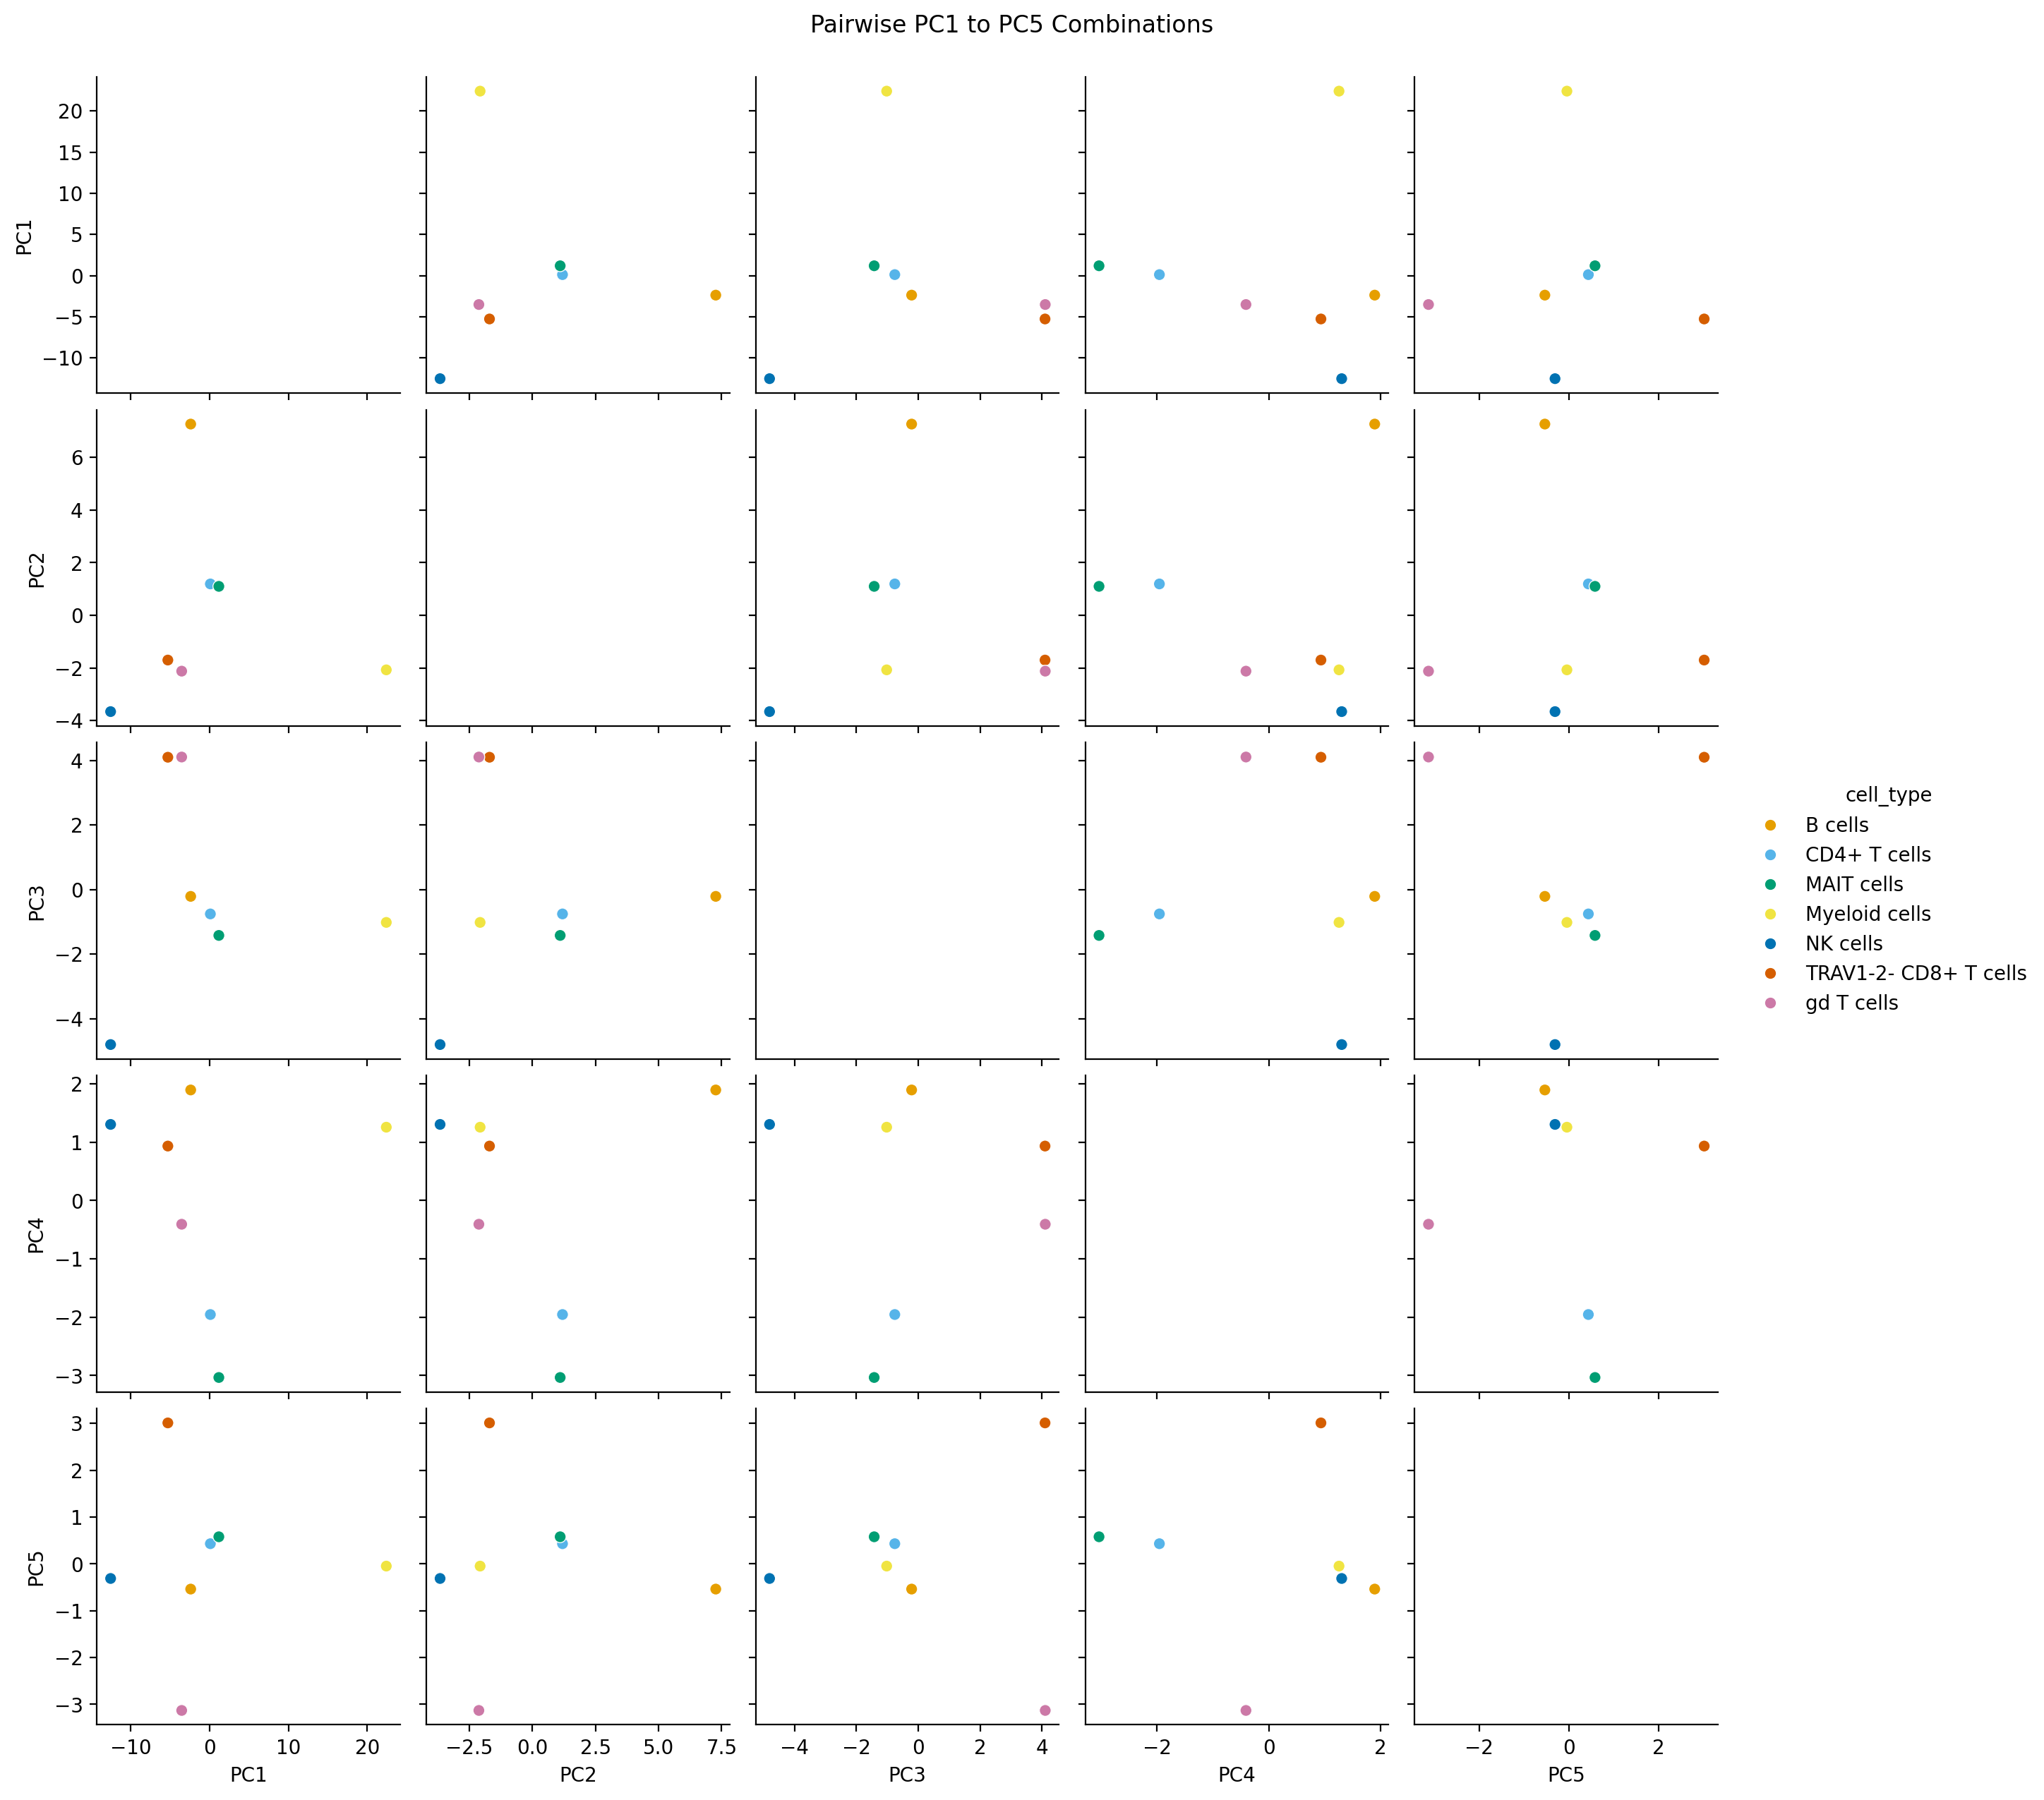

In [14]:
# - PCA analysis of feature importance
adata_feature_importance = ad.AnnData(feature_importances_df_p)
sc.pp.pca(adata_feature_importance, n_comps=5)

pca_df = pd.DataFrame(adata_feature_importance.obsm['X_pca'], columns=[f'PC{i+1}' for i in range(5)])

# - add cell type to the DataFrame
pca_df['cell_type'] = adata_feature_importance.obs.index
if True:
    # Create pairplot of all combinations of PC1 to PC6, colored by age_group
    sns.pairplot(pca_df, hue='cell_type', palette=colors_blind)  # You can choose any palette you prefer
    plt.suptitle("Pairwise PC1 to PC5 Combinations", y=1.02)
    plt.show()

In [15]:
# - analysis of loadings
cell_type = 'Myeloid cells'
pc_i = 0
explained_variance_t = .4 # used to subset top loadings


pc_loadings = pd.DataFrame({'share':adata_feature_importance.varm['PCs'][:, pc_i]}, index= adata_feature_importance.var_names)
pc_loadings.index.name = 'link'
pc_loadings = pc_loadings.sort_values(by='share', ascending=False, key=abs)

# - find out top associated links

variance_explained_df_ct = variance_explained_df.loc[cell_type].to_frame()
variance_explained_df_ct.columns = ['explained_variance']
pc_loadings_m = pc_loadings.merge(variance_explained_df_ct, left_index=True, right_index=True)
pc_loadings_m = pc_loadings_m[pc_loadings_m['explained_variance']>explained_variance_t]
print(pc_loadings_m.sort_values('share', key=abs)[::-1])

associated_links = pc_loadings_m.index

                  share  explained_variance
HINT1_HLA-DRA -0.050175            0.436258
ATP6V0C_RPS12 -0.048948            0.425833
HINT1_IFI30   -0.048189            0.487241
FCN1_HINT1    -0.048058            0.450234
HLA-DPA1_LCK  -0.047805            0.429778
...                 ...                 ...
CCL5_MARCKS   -0.025058            0.599847
CCL5_FCGRT    -0.022853            0.638786
CCL5_CFP      -0.022540            0.628887
HLA-DRA_SPON2 -0.014786            0.694854
CCL5_DAPP1    -0.014270            0.464001

[98 rows x 2 columns]


links n : (98,)  genes:  46


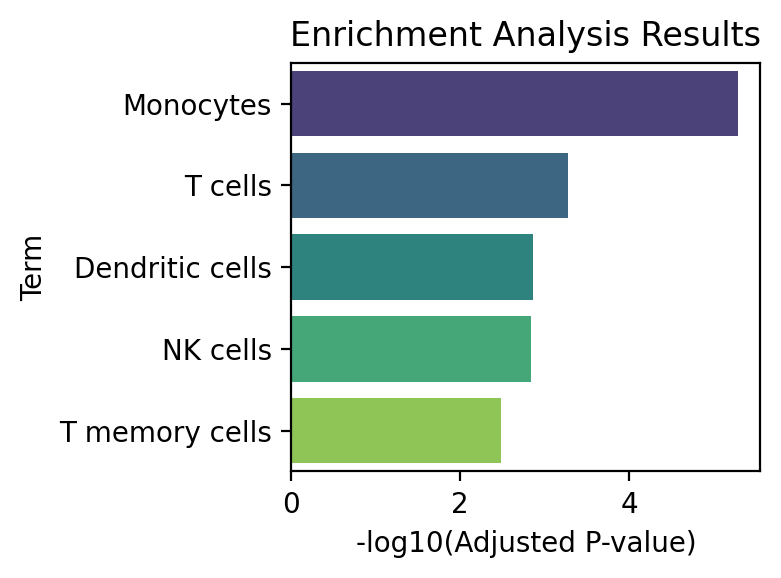

In [16]:
# Perform Over-Representation Analysis (ORA)
gg_names = np.asarray([name.split('_') for name in associated_links])
gene_names = np.unique(gg_names.flatten())
print('links n :', associated_links.shape, ' genes: ', len(gene_names))
enr = gp.enrichr(
    gene_list=list(gene_names),     # List of genes
    gene_sets='../grn_benchmark/output/panglaodb_marker_sets.gmt',  #KEGG_2021_Human 'GO_Biological_Process_2021'
    # gene_sets='GO_Biological_Process_2021',  #KEGG_2021_Human 'GO_Biological_Process_2021'
    organism='Human',         # Organism
    outdir='output/enrichr_results', # Output directory
)

enrich_rr = enr.results
enrich_rr = enrich_rr[enrich_rr['Adjusted P-value']<0.05][['Term', 'Overlap', 'Adjusted P-value', 'Genes']]
plot_enrichment(enrich_rr, figsize=(4,3))

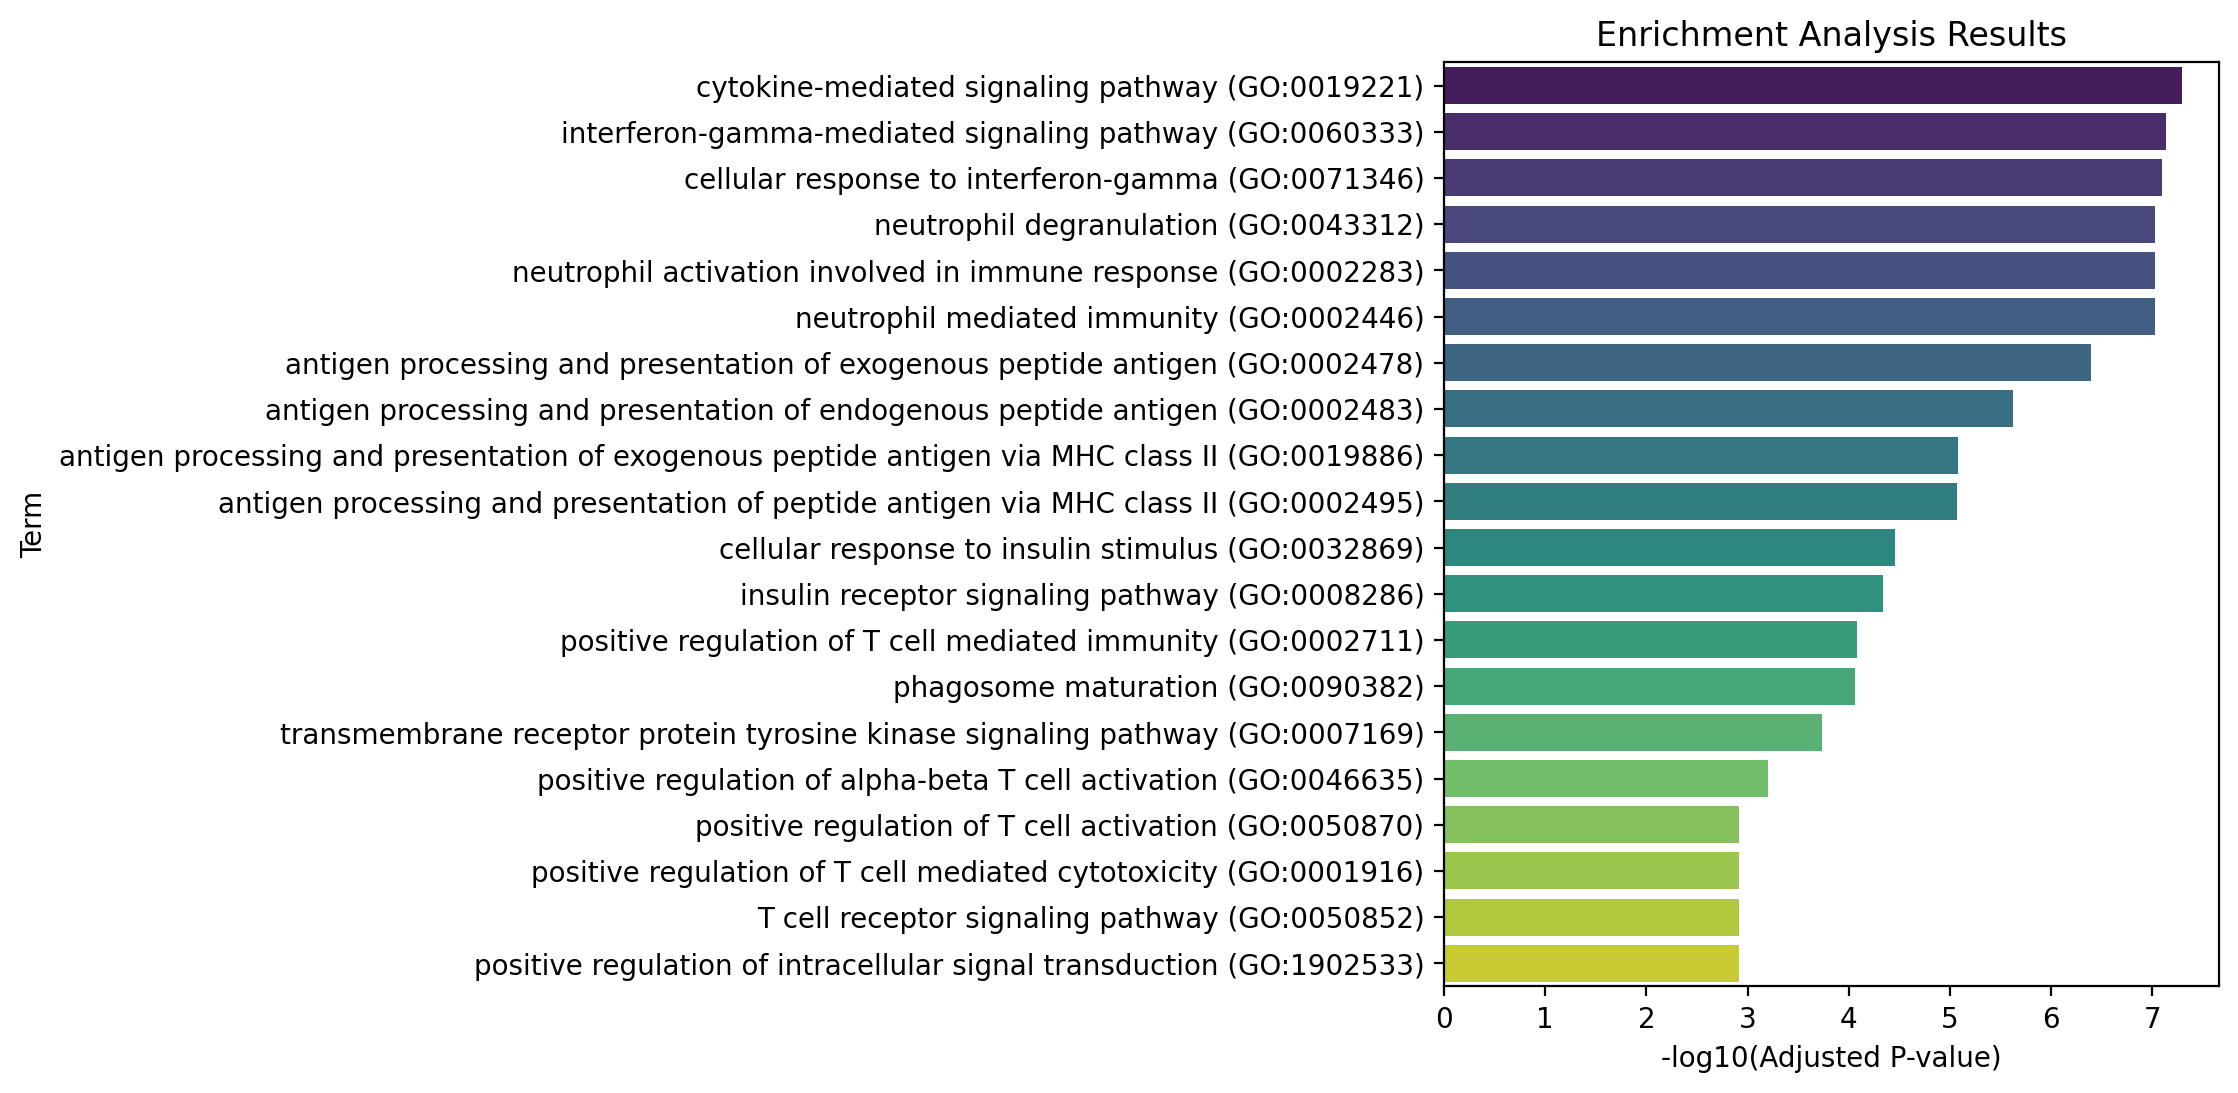

In [17]:
enr = gp.enrichr(
    gene_list=list(gene_names),     # List of genes
    # gene_sets='../grn_benchmark/output/panglaodb_marker_sets.gmt',  #KEGG_2021_Human 'GO_Biological_Process_2021'
    gene_sets='GO_Biological_Process_2021',  #KEGG_2021_Human 'GO_Biological_Process_2021'
    organism='Human',         # Organism
    outdir='output/enrichr_results', # Output directory
)

enrich_rr = enr.results
enrich_rr = enrich_rr[enrich_rr['Adjusted P-value']<0.05][['Term', 'Overlap', 'Adjusted P-value', 'Genes']]
plot_enrichment(enrich_rr.sort_values('Adjusted P-value')[:20])

# Differential correlation, cell type based

In [3]:
# dataset = 'dataset_1'
# batch_group = 'batch_1'
# adata_file=f'input/{dataset}_{batch_group}.h5ad'

mode='fisher'
# sample_age_group = '65_75'
ref_age_group = '34-'
# n_permutations=1000

# - read the data
adata = ad.read_h5ad(f'input/dataset_1.h5ad')
# - define target genes 
if True:
    genesets = get_genesets()
    target_genes = np.unique(np.concatenate(list(genesets.values())))
else:
    sig_oo[['g1', 'g2']] = sig_oo['link'].str.split('_', expand=True)
    target_genes = np.unique(sig_oo[['g1', 'g2']].values.flatten())
mask_genes = adata.var_names.isin(target_genes) 

In [30]:
from src.helper import diff_corr


i_run = 0
for batch_group in ['batch_1', 'batch_2']:
    batch_mask = adata.obs['batch_group'] == batch_group
    for i_cell_type, cell_type in enumerate(major_celltypes+['-1']):
        if cell_type == '-1':
            cell_type_mask = np.asarray([True for i in range(adata.shape[0])])
        else:
            cell_type_mask = (adata.obs['cell_type'] == cell_type)

        for sample_age_group in adata.obs['age_group'].unique():
            # - mask ctr and sample
            mask_ctr = (adata.obs['age_group'] == ref_age_group) & cell_type_mask & batch_mask
            mask_sample = (adata.obs['age_group'] == sample_age_group) & cell_type_mask & batch_mask

            adata_ctr = basic_qc(adata[mask_ctr, mask_genes], min_cells_per_gene=1000, min_genes_per_cell=10)
            adata_sample = basic_qc(adata[mask_sample, mask_genes], min_cells_per_gene=1000, min_genes_per_cell=10)

            # - harmonize feature space 
            shared_genes = np.intersect1d(adata_ctr.var_names, adata_sample.var_names)
            adata_ctr = adata_ctr[:, shared_genes]
            adata_sample = adata_sample[:, shared_genes]
            # - normalize 
            X_norm = sc.pp.normalize_total(adata_ctr, inplace=False)['X']
            adata_ctr.layers['X_norm'] = sc.pp.log1p(X_norm, copy=True)
            X_norm = sc.pp.normalize_total(adata_sample, inplace=False)['X']
            adata_sample.layers['X_norm'] = sc.pp.log1p(X_norm, copy=True)

            # - actual subset 
            expression_ctr = adata_ctr.layers['X_norm'].todense().A
            expression_sample = adata_sample.layers['X_norm'].todense().A
            gene_names = shared_genes

            # - cell type info 
            cell_type_ctr = adata_ctr.obs.cell_type
            cell_type_sample = adata_sample.obs.cell_type

            # - actuall calcualtion
            net = diff_corr(expression_ctr, expression_sample, gene_names, sig_t=1, cell_type_ctr=cell_type_ctr, cell_type_sample=cell_type_sample, mode=mode)
            net['age_group'] = sample_age_group
            net['batch_group'] = batch_group
            net['cell_type'] = cell_type
            

            # - store 
            if i_run == 0:
                net_all = net
            else:
                net_all = pd.concat([net_all, net], axis=0)
            i_run+=1
net_all.to_csv(f'output/net_all_{mode}_dataset1.csv')

shape before  (4166, 891)
shape after  (4166, 204)
shape before  (1989, 891)
shape after  (1989, 59)
shape before  (4166, 891)
shape after  (4166, 204)
shape before  (2633, 891)
shape after  (2633, 99)
shape before  (4166, 891)
shape after  (4166, 204)
shape before  (3569, 891)
shape after  (3569, 148)
shape before  (4166, 891)
shape after  (4166, 204)
shape before  (4051, 891)
shape after  (4051, 194)
shape before  (4166, 891)
shape after  (4166, 204)
shape before  (4166, 891)
shape after  (4166, 204)
shape before  (45615, 891)
shape after  (45615, 711)
shape before  (32815, 891)
shape after  (32815, 669)
shape before  (45615, 891)
shape after  (45615, 711)
shape before  (47164, 891)
shape after  (47164, 711)
shape before  (45615, 891)


In [19]:
net_all = pd.read_csv(f'output/net_all_{mode}_dataset1.csv')
net_all_sig = net_all[(net_all['adj_pvalue']<0.05) & (net_all['diff']>0.05)]
print('ratio of sig: ', net_all_sig.shape[0]/net_all.shape[0])

groups = net_all_sig.groupby(['cell_type','age_group'])


ratio of sig:  0.0021485881798995786


In [29]:
df_long = groups.get_group(('Myeloid cells','65_75'))
df_table = df_long.pivot(index='link', columns='batch_group', values='diff')
df_table

batch_group,batch_1,batch_2
link,,
ACTB_CCNL1,0.06,0.06
ACTB_CD83,0.06,0.06
ACTB_EGR1,0.10,0.10
ACTB_FOS,0.06,0.06
ACTB_FOSB,0.09,0.09
...,...,...
RPSA_SAT1,0.06,0.06
S100A10_ZFP36,0.06,0.06
SAT1_UQCRB,0.06,0.06


In [27]:
df_table.isna().any()

batch_group
batch_1    False
batch_2    False
dtype: bool

In [ ]:
def plot_joint_gene_scores(df_long, method1, method2):
    
    df_table = df_long.pivot_table(index='gene', columns='model', values='r2score', aggfunc='mean')

    # - add common gene specs 
    present_table = df_long.pivot_table(index='gene', columns='model', values='present', aggfunc='mean')
    present_table = present_table.astype(bool)

    df_table['present'] = 'None'
    df_table.loc[present_table[method1], 'present'] = method1
    df_table.loc[present_table[method2], 'present'] = method2
    df_table.loc[present_table[method1]&present_table[method2], 'present'] = 'Both'


    for name in ['None', method1, method2, 'Both']:
        mask = df_table['present'] == name
        n = (mask).sum()
        df_table.loc[mask, 'present'] += f' ({n})'

    sns.jointplot(
            data = df_table, 
            x = method1, 
            y = method2, 
            hue= 'present',   # Color points by "True"/"False"
            # markers=True,
            # kind="kde",    # Contours with kde
            # fill=False,    # Fill contour lines
            marginal_kws=dict(common_norm=False, fill=True),  # Marginal distribution,
            alpha=.5
        )
    return scores_store_table

In [23]:

sns.jointplot(, x=''

,link,ctr_corr,corr,diff,adj_pvalue,age_group,batch_group,cell_type
1343204,ACTB_CCNL1,-0.26,-0.20,0.06,0.0,65_75,batch_1,Myeloid cells
1343213,ACTB_CD83,-0.27,-0.21,0.06,0.0,65_75,batch_1,Myeloid cells
1343291,ACTB_EGR1,-0.27,-0.16,0.10,0.0,65_75,batch_1,Myeloid cells
1343325,ACTB_FOS,-0.32,-0.26,0.06,0.0,65_75,batch_1,Myeloid cells
1343326,ACTB_FOSB,-0.43,-0.34,0.09,0.0,65_75,batch_1,Myeloid cells
...,...,...,...,...,...,...,...,...
5724368,RPSA_SAT1,-0.20,-0.13,0.06,0.0,65_75,batch_2,Myeloid cells
5725470,S100A10_ZFP36,-0.08,-0.02,0.06,0.0,65_75,batch_2,Myeloid cells
5725752,SAT1_UQCRB,-0.05,0.01,0.06,0.0,65_75,batch_2,Myeloid cells
5735508,TNFAIP3_TXNIP,-0.18,-0.12,0.06,0.0,65_75,batch_2,Myeloid cells


### Compare fisher z test to permutation

In [3]:
# - compare z fisher sig links to permutation
net_permut = pd.read_csv('output/net_all_diff_permut.csv', index_col=0)
net_permut_sig = net_permut[(net_permut['adj_pvalue']<0.05) & (net_permut['diff']>0.05)].sort_values('diff', key=abs)[::-1]

net_fisher = pd.read_csv('output/net_all_diff_fisher.csv', index_col=0)
net_fisher_sig = net_fisher[(net_fisher['adj_pvalue']<0.05) & (net_fisher['diff']>0.05)].sort_values('diff', key=abs)[::-1]

print('fisher:', net_fisher_sig.index.shape, 'permut:', net_permut_sig.index.shape, ' number of shared links: ', np.intersect1d(net_fisher_sig.index, net_permut_sig.index).shape)

# - shared genes in the sig links
unique_genes_fisher = np.unique(np.asarray([link.split('_') for link in net_fisher_sig.index]).flatten())
unique_genes_permut = np.unique(np.asarray([link.split('_') for link in net_permut_sig.index]).flatten())
print('fisher:', unique_genes_fisher.shape, 'permut:', unique_genes_permut.shape, ' number of shared genes: ', np.intersect1d(unique_genes_fisher, unique_genes_permut).shape)

fisher: (1149,) permut: (1140,)  number of shared links:  (1140,)
fisher: (238,) permut: (238,)  number of shared genes:  (238,)


In [4]:
net_fisher_sig


,ctr_corr,corr,diff,adj_pvalue,cell_type
link,,,,,
HLA-A_HLA-G,0.01,0.22,0.21,0.0,-1
AREG_KLRD1,0.03,0.25,0.21,0.0,-1
B2M_HLA-B,0.34,0.55,0.20,0.0,-1
HLA-B_KLRD1,0.26,0.47,0.20,0.0,-1
HLA-B_SPON2,0.22,0.41,0.19,0.0,-1
...,...,...,...,...,...
FOS_HLA-DMA,0.16,0.22,0.06,0.0,-1
FOS_GM2A,0.09,0.16,0.06,0.0,-1
FKBP1A_HLA-DQB1,0.11,0.17,0.06,0.0,-1


### Compare permut to donor based approach

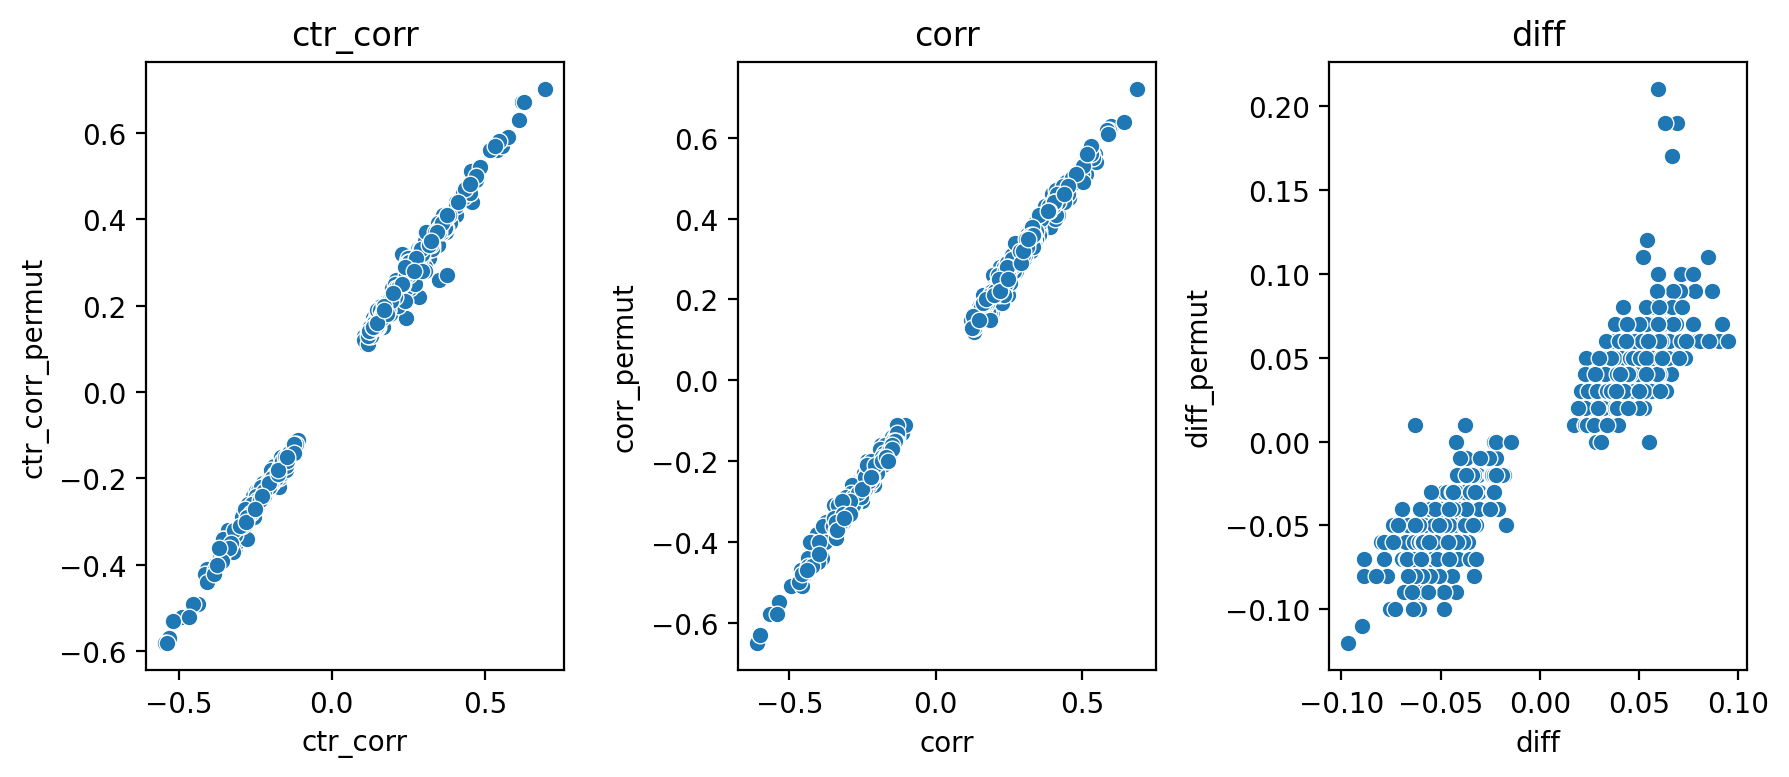

In [10]:
# - compare to previous sig links 
net = pd.read_csv('output/net_all_permut_dif_fisher.csv', index_col=0)
net = net[['ctr_corr', 'corr', 'diff', 'adj_pvalue']]

sig_oo_age = sig_oo[sig_oo.age_group=='65_75'].set_index('link')
sig_oo_age = sig_oo_age[['mean_ctr', 'mean', 'diff', 'fdr']]
sig_oo_age.columns =  ['ctr_corr','corr', 'diff', 'adj_pvalue']
sig_oo_m = sig_oo_age.merge(net, left_index=True, right_index=True, suffixes=['','_permut'])

fig, axes = plt.subplots(1, 3, figsize=(9, 4))
for i, tag in enumerate(['ctr_corr', 'corr', 'diff']):
    sns.scatterplot(sig_oo_m, x=f'{tag}',  y=f'{tag}_permut', ax=axes[i])
    axes[i].set_title(tag)
plt.tight_layout()


In [27]:
# - shared between donor sig links and permut
net_permut = pd.read_csv('output/net_all_permut_diff.csv', index_col=0)
net_permut_sig = net_permut[(net_permut['adj_pvalue']<0.05) & (net_permut['diff']>0.05)].sort_values('diff', key=abs)[::-1]

print('original:', sig_oo_age.index.shape, 'permut:', net_permut_sig.index.shape, ' number of shared links: ', np.intersect1d(sig_oo_age.index, net_permut_sig.index).shape)

original: (502,) permut: (1149,)  number of shared links:  (87,)


In [28]:
# - shared genes in the sig links
unique_genes_current = np.unique(np.asarray([link.split('_') for link in net_permut_sig.index]).flatten())
unique_genes_previous = np.unique(np.asarray([link.split('_') for link in sig_oo_age.index]).flatten())
print('original:', unique_genes_previous.shape, 'permut:', unique_genes_current.shape, ' number of shared genes: ', np.intersect1d(unique_genes_previous, unique_genes_current).shape)

original: (126,) permut: (238,)  number of shared genes:  (103,)
